<a href="https://colab.research.google.com/github/kbfkaif04/Colab-Notebooks-/blob/main/facial_keypoints_detection_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Keypoint Detection — Step-by-Step Deep Learning Project

## Objective

Build an end-to-end **facial keypoint detection** model using the Kaggle **Facial Keypoints Detection** competition dataset.

Unlike the Iris project, this is an **image regression** problem. The model receives a 96×96 grayscale face image and predicts the `(x, y)` coordinates of facial landmarks.

According to the Kaggle competition description:

- The training set contains **7,049** examples.
- The test set contains **1,783** images.
- Images are **96×96 grayscale** images.
- There are up to **15 facial keypoints**, represented by **30 coordinate values**.
- Some training rows have missing keypoint annotations.
- The competition uses **RMSE** as its evaluation metric.
- The official submission format is defined by `submissionFileFormat.csv`.

Source: [Kaggle Facial Keypoints Detection](https://www.kaggle.com/competitions/facial-keypoints-detection/overview)


## Project Workflow

1. Import libraries.
2. Locate and load the Kaggle files.
3. Inspect the dataset and missing labels.
4. Convert the pixel strings into image arrays.
5. Normalize image pixels and keypoint coordinates.
6. Visualize sample faces and landmarks.
7. Create a train/validation split.
8. Build a CNN regression model.
9. Train with a **masked loss** so missing landmarks do not corrupt training.
10. Evaluate using validation RMSE.
11. Plot training curves and prediction examples.
12. Retrain the model on all available training data.
13. Generate predictions for the Kaggle test set.
14. Create the official Kaggle submission CSV.


## 1. Import Required Libraries

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.20.0
Num GPUs Available: 0


## 2. Locate the Kaggle Dataset

On Kaggle, the dataset is normally available under `/kaggle/input/...`.

The code below searches common locations for:

- `training.csv`
- `test.csv`
- `submissionFileFormat.csv`

For Google Colab, you can either upload these files manually or change the paths below to your uploaded files.


In [ ]:
from pathlib import Path

train_path = Path("/content/training.csv")
test_path = Path("/content/test.csv")
lookup_path = Path("/content/IdLookupTable.csv")
sample_submission_path = Path("/content/SampleSubmission.csv")

print("training.csv:", train_path)
print("test.csv:", test_path)
print("IdLookupTable.csv:", lookup_path)
print("SampleSubmission.csv:", sample_submission_path)

required_files = [
    train_path,
    test_path,
    lookup_path,
    sample_submission_path
]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}"
        )


training.csv: /content/training.csv
test.csv: /content/test.csv
IdLookupTable.csv: /content/IdLookupTable.csv
SampleSubmission.csv: /content/SampleSubmission.csv


## 3. Load the Data

In [ ]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
lookup_df = pd.read_csv(lookup_path)
sample_submission = pd.read_csv(sample_submission_path)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Lookup shape:", lookup_df.shape)
print("Sample submission shape:", sample_submission.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nLookup columns:")
print(lookup_df.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

display(train_df.head())
display(lookup_df.head())
display(sample_submission.head())

Training shape: (7049, 31)
Test shape: (1783, 2)
Lookup shape: (27124, 4)
Sample submission shape: (27124, 2)

Training columns:
['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x', 'right_eye_center_y', 'left_eye_inner_corner_x', 'left_eye_inner_corner_y', 'left_eye_outer_corner_x', 'left_eye_outer_corner_y', 'right_eye_inner_corner_x', 'right_eye_inner_corner_y', 'right_eye_outer_corner_x', 'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x', 'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x', 'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x', 'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x', 'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y', 'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x', 'mouth_right_corner_y', 'mouth_center_top_lip_x', 'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x', 'mouth_center_bottom_lip_y', 'Image']

Test columns:
['ImageId', 'Image']

Lookup columns:
['RowId', 'ImageId', 'FeatureName', 'Locat

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


,RowId,ImageId,FeatureName,Location
0,1,1,left_eye_center_x,NaN
1,2,1,left_eye_center_y,NaN
2,3,1,right_eye_center_x,NaN
3,4,1,right_eye_center_y,NaN
4,5,1,left_eye_inner_corner_x,NaN


,RowId,Location
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## 4. Inspect Columns and Missing Values

The training file contains facial landmark coordinates followed by the `Image` column.

Because some landmarks are not annotated in some training images, missing values are expected. We will keep those images and use a **masked loss** during training so only available coordinates contribute to the loss.


In [ ]:
print("Training columns:")
print(train_df.columns.tolist())

print("\nMissing values in the training data:")
missing = train_df.isna().sum().sort_values(ascending=False)

display(missing.to_frame("missing_count").head(35))

print(
    "\nRows with at least one missing keypoint:",
    train_df.iloc[:, :-1].isna().any(axis=1).sum()
)

print(
    "Rows with all keypoints present:",
    train_df.iloc[:, :-1].notna().all(axis=1).sum()
)


Training columns:
['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x', 'right_eye_center_y', 'left_eye_inner_corner_x', 'left_eye_inner_corner_y', 'left_eye_outer_corner_x', 'left_eye_outer_corner_y', 'right_eye_inner_corner_x', 'right_eye_inner_corner_y', 'right_eye_outer_corner_x', 'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x', 'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x', 'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x', 'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x', 'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y', 'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x', 'mouth_right_corner_y', 'mouth_center_top_lip_x', 'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x', 'mouth_center_bottom_lip_y', 'Image']

Missing values in the training data:


,missing_count
left_eyebrow_outer_end_x,4824
left_eyebrow_outer_end_y,4824
right_eyebrow_outer_end_x,4813
right_eyebrow_outer_end_y,4813
left_eye_outer_corner_y,4782
left_eye_outer_corner_x,4782
right_eye_inner_corner_x,4781
right_eye_outer_corner_y,4781
right_eye_inner_corner_y,4781
right_eye_outer_corner_x,4781



Rows with at least one missing keypoint: 4909
Rows with all keypoints present: 2140


## 5. Prepare Images and Keypoint Targets

Each `Image` entry is a string containing 9,216 grayscale pixel values (`96 × 96`).

We convert those strings into NumPy arrays and reshape them to:

```text
(samples, 96, 96, 1)
```

Keypoint coordinates are normalized to the range `[0, 1]` by dividing x-coordinates by 96 and y-coordinates by 96.


In [ ]:
IMAGE_SIZE = 96
NUM_KEYPOINTS = 30

target_columns = [c for c in train_df.columns if c != "Image"]

assert len(target_columns) == NUM_KEYPOINTS, (
    f"Expected {NUM_KEYPOINTS} coordinate columns, found {len(target_columns)}"
)


def parse_images(image_series):
    images = np.zeros((len(image_series), IMAGE_SIZE, IMAGE_SIZE, 1), dtype=np.float32)

    for i, image_str in enumerate(image_series):
        pixels = np.fromstring(image_str, sep=" ", dtype=np.float32)

        if pixels.size != IMAGE_SIZE * IMAGE_SIZE:
            raise ValueError(
                f"Image {i} contains {pixels.size} pixels; "
                f"expected {IMAGE_SIZE * IMAGE_SIZE}."
            )

        images[i, :, :, 0] = pixels.reshape(IMAGE_SIZE, IMAGE_SIZE)

    return images / 255.0


X_all = parse_images(train_df["Image"])
X_test = parse_images(test_df["Image"])

# Raw coordinates
y_raw = train_df[target_columns].to_numpy(dtype=np.float32)

# Mask: 1 where a coordinate is present, 0 where it is missing
mask_all = (~np.isnan(y_raw)).astype(np.float32)

# Replace missing coordinates with zero temporarily.
# The mask tells the loss function to ignore them.
y_filled = np.nan_to_num(y_raw, nan=0.0)

# Normalize coordinates to approximately [0, 1]
x_indices = np.arange(0, NUM_KEYPOINTS, 2)
y_indices = np.arange(1, NUM_KEYPOINTS, 2)

y_filled[:, x_indices] /= IMAGE_SIZE
y_filled[:, y_indices] /= IMAGE_SIZE

print("X_all shape:", X_all.shape)
print("y_filled shape:", y_filled.shape)
print("mask shape:", mask_all.shape)


X_all shape: (7049, 96, 96, 1)
y_filled shape: (7049, 30)
mask shape: (7049, 30)


## 6. Visualize Sample Images and Keypoints

Visualization is essential for checking that the images and coordinates were decoded correctly before training.


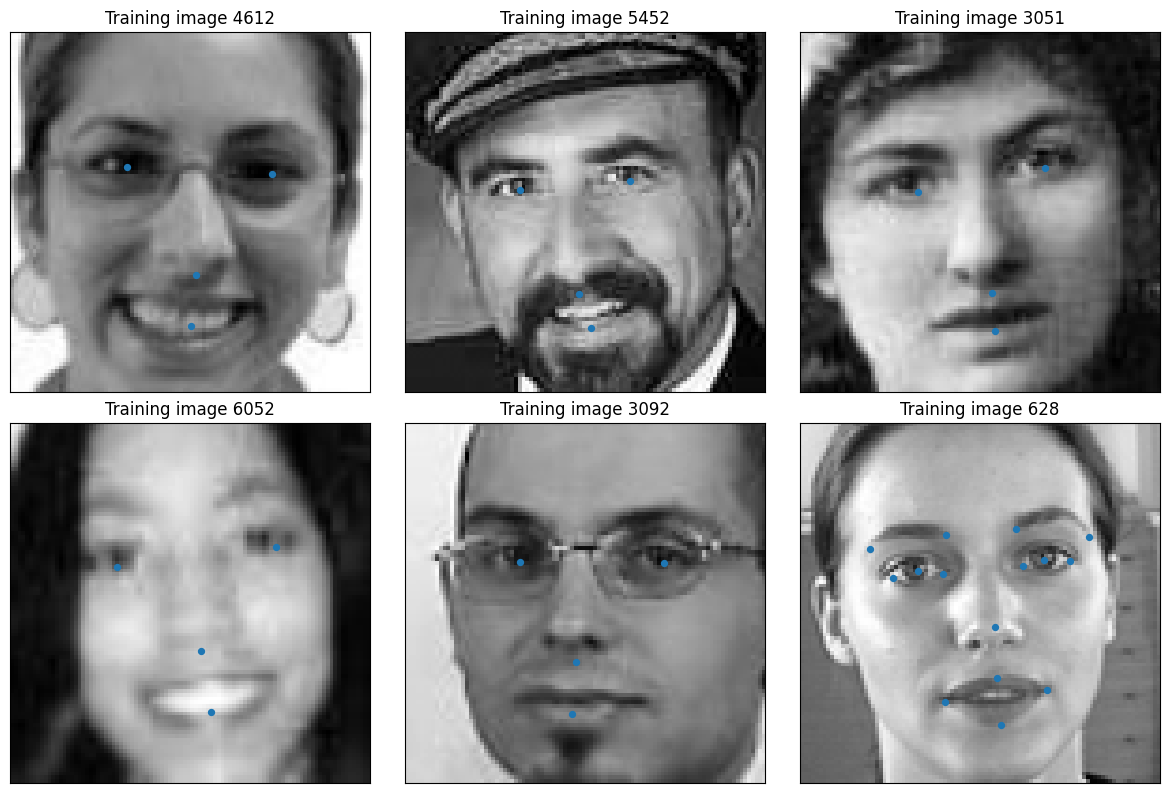

In [ ]:
def plot_face(image, keypoints=None, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    ax.imshow(image.squeeze(), cmap="gray")

    if keypoints is not None:
        points = keypoints.reshape(-1, 2)
        valid = np.all(np.isfinite(points), axis=1)

        ax.scatter(
            points[valid, 0],
            points[valid, 1],
            s=18
        )

    ax.set_xticks([])
    ax.set_yticks([])

    if title:
        ax.set_title(title)

    return ax


rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_all), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, idx in zip(axes.ravel(), sample_indices):
    kp = train_df[target_columns].iloc[idx].to_numpy(dtype=np.float32)
    plot_face(
        X_all[idx],
        kp,
        ax=ax,
        title=f"Training image {idx}"
    )

plt.tight_layout()
plt.show()


## 7. Train/Validation Split

We reserve 15% of the training images for validation.

The validation set is used to monitor generalization during model development. The final Kaggle test set remains completely separate.


In [ ]:
indices = np.arange(len(X_all))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    shuffle=True
)

X_train = X_all[train_idx]
X_val = X_all[val_idx]

y_train = y_filled[train_idx]
y_val = y_filled[val_idx]

mask_train = mask_all[train_idx]
mask_val = mask_all[val_idx]

print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Test images:", X_test.shape)


Training images: (5991, 96, 96, 1)
Validation images: (1058, 96, 96, 1)
Test images: (1783, 96, 96, 1)


## 8. Masked Mean Squared Error

Some training examples do not contain all 30 coordinates.

A standard MSE would incorrectly treat those missing coordinates as real targets. Instead, the custom loss below uses a **mask** and averages the squared error only over coordinates that are actually available.

The model receives 30 predictions. The target passed to Keras contains both:

- the normalized coordinate values (30 values)
- the availability mask (30 values)


In [ ]:
def masked_mse_loss(y_true_with_mask, y_pred):
    y_true = y_true_with_mask[:, :NUM_KEYPOINTS]
    mask = y_true_with_mask[:, NUM_KEYPOINTS:]

    squared_error = tf.square(y_true - y_pred)
    masked_error = squared_error * mask

    return (
        tf.reduce_sum(masked_error, axis=1)
        / tf.maximum(tf.reduce_sum(mask, axis=1), 1.0)
    )


def pack_targets(y, mask):
    return np.concatenate([y, mask], axis=1).astype(np.float32)


y_train_packed = pack_targets(y_train, mask_train)
y_val_packed = pack_targets(y_val, mask_val)

print("Packed training target shape:", y_train_packed.shape)


Packed training target shape: (5991, 60)


## 9. Build a CNN Regression Model

This convolutional neural network learns spatial patterns directly from the face images.

The architecture uses:

- Convolution layers for visual feature extraction.
- Batch normalization for stable optimization.
- Max pooling to reduce spatial size.
- Dropout to reduce overfitting.
- Dense layers to regress the 30 landmark coordinates.

The final activation is `sigmoid` because our target coordinates have been normalized to approximately `[0, 1]`.


In [ ]:
def build_model():

    inputs = keras.Input(
        shape=(IMAGE_SIZE, IMAGE_SIZE, 1)
    )

    x = inputs

    # Block 1
    x = layers.Conv2D(
        16, 3, padding="same", activation="relu"
    )(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 2
    x = layers.Conv2D(
        32, 3, padding="same", activation="relu"
    )(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 3
    x = layers.Conv2D(
        64, 3, padding="same", activation="relu"
    )(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 4
    x = layers.Conv2D(
        128, 3, padding="same", activation="relu"
    )(x)
    x = layers.MaxPooling2D(2)(x)

    # Regression head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(
        NUM_KEYPOINTS,
        activation="sigmoid"
    )(x)

    return keras.Model(inputs, outputs)


model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=masked_mse_loss
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,886 (538.62 KB)

 Trainable params: 137,886 (538.62 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Train the CNN

We use:

- `EarlyStopping` to stop when validation performance stops improving.
- `ReduceLROnPlateau` to lower the learning rate when progress slows.
- The best validation weights are restored at the end.

> **GPU recommended:** Training is significantly faster on a Kaggle/Colab GPU.


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train_packed,
    validation_data=(X_val, y_val_packed),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 66s 334ms/step - loss: 0.0037 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 63s 334ms/step - loss: 0.0020 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 333ms/step - loss: 0.0019 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 341ms/step - loss: 0.0019 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0019
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
188/188 ━━━━━━━━━━━━━━━━━━━━ 80s 331ms/step - loss: 0.0018 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 340ms/step - loss: 0.0018 - val_loss: 0.0016 - learning_rate: 5.0000e-04
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.0018
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
188/188 ━━━━━━━━━━━━━━━━━━━━ 61s 326ms/

## 11. Plot Training Curves

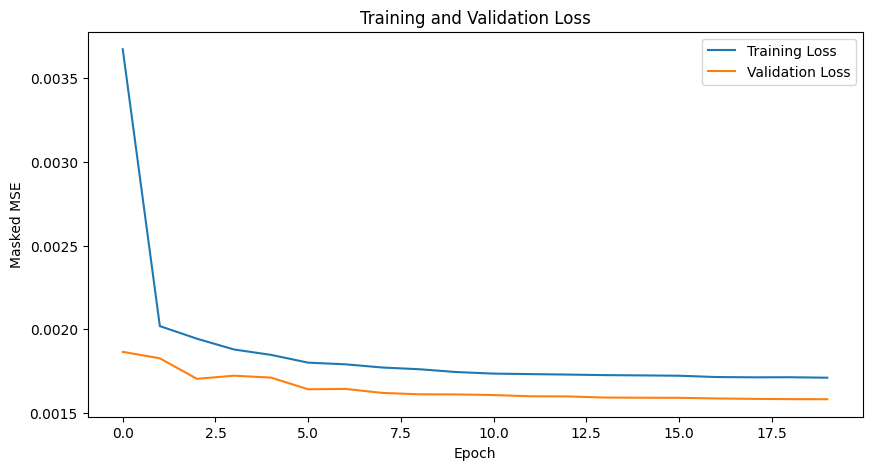

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE")
plt.legend()
plt.show()


## 12. Evaluate Validation RMSE

Kaggle evaluates this competition with **Root Mean Squared Error (RMSE)**.

We calculate RMSE using the validation images and only the coordinates that are actually annotated.


In [ ]:
val_pred = model.predict(X_val, batch_size=128, verbose=0)

val_true = y_val
val_mask = mask_val

mse = (
    np.sum((val_true - val_pred) ** 2 * val_mask)
    / np.sum(val_mask)
)

val_rmse_normalized = np.sqrt(mse)

# Convert normalized coordinate error back to pixel units.
val_rmse_pixels = val_rmse_normalized * IMAGE_SIZE

print(f"Validation RMSE (normalized): {val_rmse_normalized:.6f}")
print(f"Validation RMSE (pixels):     {val_rmse_pixels:.4f}")


Validation RMSE (normalized): 0.038588
Validation RMSE (pixels):     3.7044


## 13. Visualize Validation Predictions

We compare predicted landmarks against the known validation landmarks.

This qualitative check is important because an ML metric alone cannot show whether the predicted points are located on meaningful facial features.


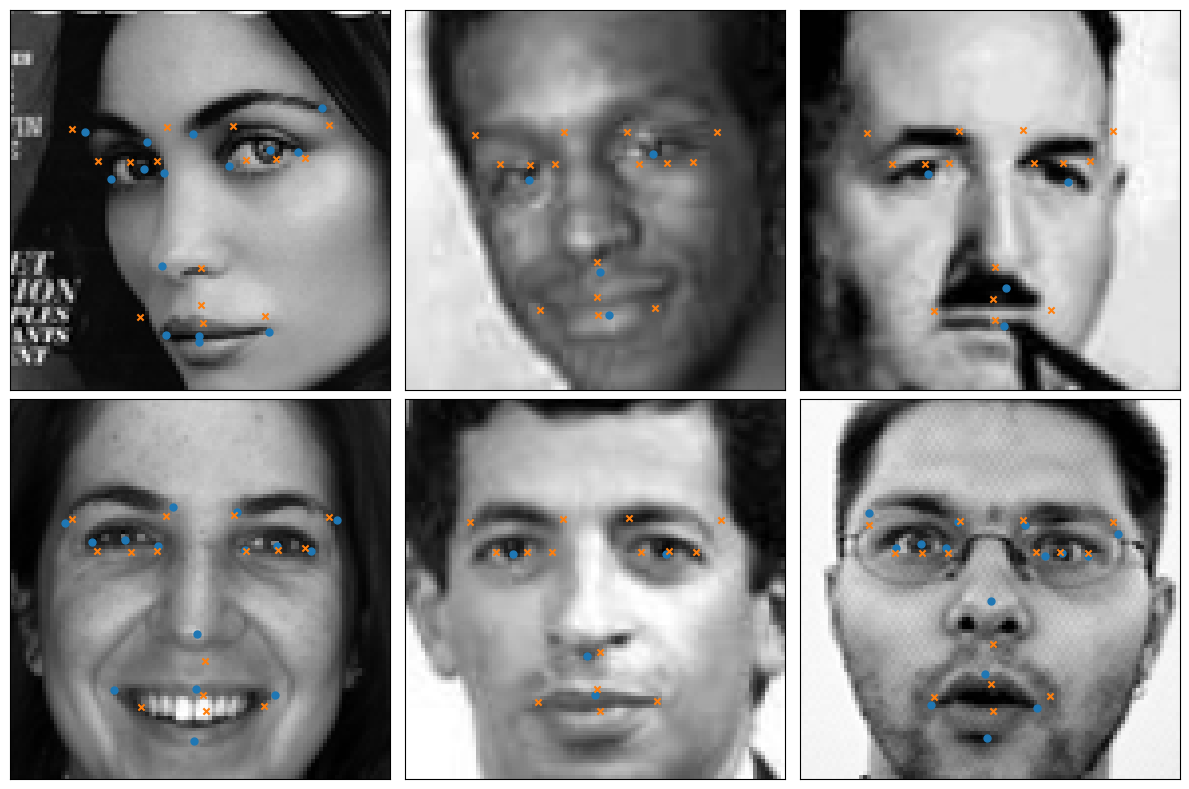

In [ ]:
sample_val = np.random.default_rng(SEED).choice(
    len(X_val),
    size=min(6, len(X_val)),
    replace=False
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, idx in zip(axes.ravel(), sample_val):
    true_points = y_val[idx].copy()
    pred_points = val_pred[idx].copy()

    # Convert back to pixel coordinates
    for j in range(0, NUM_KEYPOINTS, 2):
        true_points[j] *= IMAGE_SIZE
        true_points[j + 1] *= IMAGE_SIZE
        pred_points[j] *= IMAGE_SIZE
        pred_points[j + 1] *= IMAGE_SIZE

    ax.imshow(X_val[idx].squeeze(), cmap="gray")

    true_xy = true_points.reshape(-1, 2)
    pred_xy = pred_points.reshape(-1, 2)

    available = mask_val[idx].reshape(-1, 2).all(axis=1)

    ax.scatter(
        true_xy[available, 0],
        true_xy[available, 1],
        s=25,
        label="True"
    )

    ax.scatter(
        pred_xy[:, 0],
        pred_xy[:, 1],
        s=20,
        marker="x",
        label="Predicted"
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## 14. Train the Final Model on All Available Training Images

After model development, we can retrain using all 7,049 labeled training examples.

The validation set is no longer needed for early stopping here, so we use the best epoch count found during the first training run.


In [ ]:
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

print("Best validation epoch:", best_epoch)

final_model = build_model()

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_mse_loss
)

all_targets_packed = pack_targets(y_filled, mask_all)

final_history = final_model.fit(
    X_all,
    all_targets_packed,
    epochs=best_epoch,
    batch_size=64,
    verbose=1
)


Best validation epoch: 20
Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 73s 642ms/step - loss: 0.0045
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 72s 647ms/step - loss: 0.0022
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 72s 646ms/step - loss: 0.0020
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 73s 657ms/step - loss: 0.0020
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 72s 646ms/step - loss: 0.0019
Epoch 6/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 72s 646ms/step - loss: 0.0019
Epoch 7/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 82s 646ms/step - loss: 0.0019
Epoch 8/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 82s 646ms/step - loss: 0.0018
Epoch 9/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 81s 643ms/step - loss: 0.0018
Epoch 10/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 72s 646ms/step - loss: 0.0018
Epoch 11/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 82s 650ms/step - loss: 0.0018
Epoch 12/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 82s 651ms/step - loss: 0.0018
Epoch 13/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 73s 654ms/step - loss: 0.0017
Epoch 14/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 82s 653ms/step - lo

## 15. Generate Test Predictions

The Kaggle test images contain no keypoint labels. We therefore predict all 30 coordinates for every test image.

The model outputs normalized coordinates, so we convert them back to the original 96×96 pixel coordinate system.


In [ ]:
test_pred_normalized = final_model.predict(
    X_test,
    batch_size=128,
    verbose=1
)

test_pred_pixels = test_pred_normalized.copy()

for j in range(0, NUM_KEYPOINTS, 2):
    test_pred_pixels[:, j] *= IMAGE_SIZE
    test_pred_pixels[:, j + 1] *= IMAGE_SIZE

# Keep coordinates within valid image boundaries.
test_pred_pixels = np.clip(
    test_pred_pixels,
    0,
    IMAGE_SIZE - 1
)

prediction_df = pd.DataFrame(
    test_pred_pixels,
    columns=target_columns
)

prediction_df.insert(
    0,
    "ImageId",
    np.arange(1, len(test_df) + 1)
)

display(prediction_df.head())


14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 463ms/step


,ImageId,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
0,1,68.245995,36.419617,28.886990,35.449078,60.727676,36.319176,74.135468,37.246162,34.954620,...,48.043121,59.219490,63.476143,76.533539,32.588215,75.805588,47.770851,71.015190,47.853951,80.100204
1,2,69.416061,35.497147,27.467564,35.354687,61.155693,36.124565,75.876152,36.527615,34.476219,...,47.385330,62.345383,64.388199,78.700294,31.515776,78.672302,47.576012,74.130959,47.733818,81.654190
2,3,67.549759,36.520153,30.111660,36.420757,59.699364,36.094940,73.286514,36.278400,35.957779,...,50.426250,61.897537,63.752960,74.585052,33.343948,75.123924,49.203308,71.245895,49.997101,79.108505
3,4,68.242233,36.762512,29.456955,37.212440,59.342194,37.032516,73.673279,37.326706,35.961205,...,49.272896,64.079391,63.967712,76.719307,32.895897,77.096848,48.661800,74.318192,49.397179,79.005516
4,5,68.298218,36.209892,28.288986,35.943989,60.644753,36.793961,74.165710,38.141567,34.949295,...,48.053524,58.864414,62.948807,77.058670,32.426979,76.434525,47.835804,70.902328,48.058418,80.936859


## 16. Create the Official Kaggle Submission CSV

Kaggle expects the submission format specified in `submissionFileFormat.csv`.

That file contains:

- `RowId`
- `ImageId`
- `FeatureName`
- `Location`

We use it as the authoritative row order and fill in our predicted location for each requested feature.


In [ ]:
# Convert predictions to a DataFrame
prediction_df = pd.DataFrame(
    test_pred_pixels,
    columns=target_columns
)

# Image IDs correspond to test image rows
prediction_df.insert(
    0,
    "ImageId",
    np.arange(1, len(test_df) + 1)
)

# Convert predictions from wide to long format
long_predictions = prediction_df.melt(
    id_vars="ImageId",
    var_name="FeatureName",
    value_name="Location"
)

# ------------------------------------------------------------
# Use IdLookupTable to select ONLY the coordinates
# requested by the Kaggle competition.
# ------------------------------------------------------------

lookup = lookup_df[["RowId", "ImageId", "FeatureName"]].copy()

submission = lookup.merge(
    long_predictions,
    on=["ImageId", "FeatureName"],
    how="left"
)

# Keep only the columns Kaggle expects in the actual submission
submission = submission[
    ["RowId", "Location"]
]

# Check for missing predictions
missing_count = submission["Location"].isna().sum()

print("Missing predictions:", missing_count)

if missing_count > 0:
    raise ValueError(
        f"{missing_count} rows are missing predictions. "
        "Check ImageId/FeatureName matching."
    )

# Save submission
submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission shape:", submission.shape)

display(submission.head(10))

Missing predictions: 0
Submission shape: (27124, 2)


,RowId,Location
0,1,68.245995
1,2,36.419617
2,3,28.886990
3,4,35.449078
4,5,60.727676
5,6,36.319176
6,7,74.135468
7,8,37.246162
8,9,34.954620
9,10,36.152664


## 17. Validate the Submission File

Before uploading, verify that:

1. The columns match the competition format.
2. The number of rows matches `submissionFileFormat.csv`.
3. There are no missing predictions.


In [ ]:
print("Submission columns:", submission.columns.tolist())
print("Expected columns:", sample_submission.columns.tolist())

print("Rows in sample format:", len(sample_submission))
print("Rows in submission:    ", len(submission))

print("Missing predictions:", submission["Location"].isna().sum())

assert submission.columns.tolist() == sample_submission.columns.tolist()
assert len(submission) == len(sample_submission)
assert submission["Location"].notna().all()

print("
✅ Submission file is structurally valid.")


## 18. Save the Trained Model

Saving the final model lets you reuse it later without retraining from scratch.


In [ ]:
model_path = "facial_keypoints_cnn.keras"

final_model.save(model_path)

print("Model saved to:", Path(model_path).resolve())


## 19. Final Conclusion

This project implemented a complete CNN-based facial landmark regression pipeline.

### Main points

- Face images were decoded from the Kaggle `Image` column.
- Pixel values were normalized to `[0, 1]`.
- Keypoint coordinates were normalized to the same scale.
- Missing keypoint annotations were handled using a masked loss instead of dropping a large number of training images.
- A convolutional neural network learned the relationship between face appearance and landmark coordinates.
- Validation RMSE was used because **RMSE is the official Kaggle competition metric**.
- The final model was retrained using all available training examples.
- A Kaggle-compatible `submission.csv` was generated using the official submission format.

### Output files

The notebook produces:

```text
submission.csv
facial_keypoints_cnn.keras
```

The `submission.csv` file is the file to upload to the Kaggle competition submission page.
